# **<span style="color: #c9a84c;">𓅄 Phase 1 - CNN Baseline: ResNet-18 on Glyph2025</span>**

<hr style="height: 6px; width: 100%; background: linear-gradient(90deg, transparent, #c9a84c, #f0d080, #c9a84c, transparent); border: none; margin-top: 10px; margin-bottom: 10px;">

## <span style="color: #f0d080;">Contextual Sign Disambiguation: Moving from Sign Classification to Automated Sentence Translation</span>

<span style="color: #63ace0;">**CS437 / CS5317 / EE414 / EE513 - Deep Learning, Spring 2026**</span>

<span>**Authors:** 𓁐 Maryem Mahmood and Zehra Talat</span>

---

## **<span style="color: #c9a84c;">𓆣 Phase 1 Overview</span>**

<span style="color: #a8c4d8;">We train **ResNet-18** (ImageNet pretrained) on the **Glyph2025** merged dataset using a two-phase frozen training strategy to prevent overfitting.</span>

| Component | Choice | Reason |
|---|---|---|
| **Dataset** | Glyph2025 (13,287 imgs, 352 classes) | Full merged dataset - more diversity |
| **Model** | ResNet-18 (ImageNet pretrained) | Academically standard for small datasets |
| **Strategy** | Phase 3a: frozen backbone, Phase 3b: unfreeze Layer 4 | Prevents overfitting on limited data |
| **Feature dim** | 512 | Used as input to Phase 3 Transformer |


# **<span style="color: #c9a84c;">⚙ Section 0 - Environment Setup</span>**

In [1]:
import os, json, random, warnings, time, copy
from pathlib import Path
from collections import defaultdict, Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                              f1_score, precision_score, recall_score,
                              accuracy_score, top_k_accuracy_score)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as transforms
import torchvision.models as models

warnings.filterwarnings('ignore')
random.seed(42); np.random.seed(42); torch.manual_seed(42)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'Device  : {DEVICE}')
print(f'PyTorch : {torch.__version__}')
if torch.cuda.is_available():
    print(f'GPU     : {torch.cuda.get_device_name()}')
    print(f'VRAM    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
print('\n✓ Environment ready.')

Device  : cuda
PyTorch : 2.10.0+cu128
GPU     : Tesla T4
VRAM    : 15.6 GB

✓ Environment ready.


# **<span style="color: #c9a84c;">𓇋 Section 1 - Glyph2025 Dataset Loading</span>**

<hr style="height: 6px; width: 100%; background: linear-gradient(90deg, transparent, #c9a84c, #f0d080, #c9a84c, transparent); border: none; margin-top: 10px; margin-bottom: 10px;">

<span style="color: #a8c4d8;">The **Glyph2025** dataset is the merged combination of two sources:</span>

- **Fuentes-Ferrer / EHT** (9,703 images, 310 classes) - stone stelae, carved and painted
- **Franken / OBC306** (4,210 images, 171 classes) - Pyramid of Unas, 10 wall photographs

Combined: **13,287 images across 352 Gardiner sign classes**, deduplicated and lowercase-normalized.

> Upload Glyph2025 as a Kaggle dataset and set `GLYPH_ROOT` below.


In [2]:
# PATHS - adjust for your Kaggle setup
# Upload Glyph2025 folder as a Kaggle dataset named 'glyph2025'

from pathlib import Path
import re

GLYPH_ROOT = Path('/kaggle/input/datasets/maryemmahmood/glyph2025/Glyph2025')

assert GLYPH_ROOT.exists(), f'Not found: {GLYPH_ROOT} - check dataset path'
print(f'Dataset root: {GLYPH_ROOT}')
print(f'Class folders: {len([d for d in GLYPH_ROOT.iterdir() if d.is_dir()])}')


Dataset root: /kaggle/input/datasets/maryemmahmood/glyph2025/Glyph2025
Class folders: 352


In [3]:
# SCAN GLYPH2025 - each subfolder is a Gardiner sign class
# Folder names are lowercase Gardiner codes: a1, g17, n35 etc.

import pandas as pd
import numpy as np
from collections import Counter, defaultdict

VALID_EXTS = {'.jpg', '.jpeg', '.png', '.bmp'}
records = []

for class_dir in sorted(GLYPH_ROOT.iterdir()):
    if class_dir.is_dir():
        for img_path in class_dir.glob('*'):
            if img_path.suffix.lower() in VALID_EXTS:
                # Check if Franken image (filename: XXXXXX_LABEL.png)
                is_franken = bool(re.match(r'^\d{6}_', img_path.name))
                records.append({
                    'path'      : str(img_path),
                    'label'     : class_dir.name.upper(),  # uppercase for consistency
                    'is_franken': is_franken,
                    'plate'     : int(img_path.name[:2]) if is_franken else -1,
                    'index'     : int(img_path.name[2:6]) if is_franken else -1,
                })

df_all       = pd.DataFrame(records)
class_counts = df_all['label'].value_counts().sort_values(ascending=False)

print('=' * 52)
print('  GLYPH2025 DATASET - INVENTORY')
print('=' * 52)
print(f'  Total images  : {len(df_all):,}')
print(f'  Total classes : {df_all["label"].nunique()}')
print(f'  Max per class : {class_counts.max()} [{class_counts.idxmax()}]')
print(f'  Min per class : {class_counts.min()}')
print(f'  Median        : {class_counts.median():.0f}')
print(f'  Franken imgs  : {df_all["is_franken"].sum():,}')
print(f'  EHT imgs      : {(~df_all["is_franken"]).sum():,}')
print('=' * 52)
df_all.head(5)


  GLYPH2025 DATASET - INVENTORY
  Total images  : 13,287
  Total classes : 352
  Max per class : 942 [N35]
  Min per class : 1
  Median        : 6
  Franken imgs  : 3,584
  EHT imgs      : 9,703


,path,label,is_franken,plate,index
0,/kaggle/input/datasets/maryemmahmood/glyph2025...,A1,False,-1,-1
1,/kaggle/input/datasets/maryemmahmood/glyph2025...,A1,False,-1,-1
2,/kaggle/input/datasets/maryemmahmood/glyph2025...,A1,False,-1,-1
3,/kaggle/input/datasets/maryemmahmood/glyph2025...,A1,False,-1,-1
4,/kaggle/input/datasets/maryemmahmood/glyph2025...,A1,False,-1,-1


In [4]:
# FILTER + ENCODE LABELS + STRATIFIED SPLIT
from sklearn.model_selection import train_test_split

# Keep classes with >= 7 samples
MIN_SAMPLES = 7
valid_cls   = class_counts[class_counts >= MIN_SAMPLES].index
df_filtered = df_all[df_all['label'].isin(valid_cls)].reset_index(drop=True).copy()

label_to_idx = {lbl: i for i, lbl in enumerate(sorted(valid_cls))}
idx_to_label = {i: lbl for lbl, i in label_to_idx.items()}
df_filtered['label_idx'] = df_filtered['label'].map(label_to_idx)
NUM_CLASSES  = len(label_to_idx)

# Stratified 70/15/15 split
df_train, df_temp = train_test_split(df_filtered, test_size=0.30,
                                      stratify=df_filtered['label_idx'], random_state=42)
df_val, df_test   = train_test_split(df_temp, test_size=0.50,
                                      stratify=df_temp['label_idx'], random_state=42)

print(f'Classes (>= {MIN_SAMPLES} samples) : {NUM_CLASSES}')
print(f'Total images used              : {len(df_filtered):,}')
print(f'Train                          : {len(df_train):,} ({100*len(df_train)/len(df_filtered):.0f}%)')
print(f'Val                            : {len(df_val):,} ({100*len(df_val)/len(df_filtered):.0f}%)')
print(f'Test                           : {len(df_test):,} ({100*len(df_test)/len(df_filtered):.0f}%)')

# Leakage check
s_tr = set(df_train['path']); s_va = set(df_val['path']); s_te = set(df_test['path'])
print(f'\nLeakage check:')
print(f'  Train vs Val  : {len(s_tr & s_va)} - {"LEAKAGE" if s_tr & s_va else "Clean"}')
print(f'  Train vs Test : {len(s_tr & s_te)} - {"LEAKAGE" if s_tr & s_te else "Clean"}')


Classes (>= 7 samples) : 176
Total images used              : 12,836
Train                          : 8,985 (70%)
Val                            : 1,925 (15%)
Test                           : 1,926 (15%)

Leakage check:
  Train vs Val  : 0 - Clean
  Train vs Test : 0 - Clean


# **<span style="color: #c9a84c;">𓆣 Section 2 - Data Pipeline</span>**

<hr style="height: 6px; width: 100%; background: linear-gradient(90deg, transparent, #c9a84c, #f0d080, #c9a84c, transparent); border: none; margin-top: 10px; margin-bottom: 10px;">

<span style="color: #a8c4d8;">**Augmentation** is applied only to the training set. Val and test use deterministic preprocessing only.</span>

**𓂋 Training augmentation:**
- RandomResizedCrop(224) - zoom variation across photo sources
- RandomHorizontalFlip - hieroglyphs can face either direction
- RandomRotation(12) - inscriptions carved at slight angles
- ColorJitter - handles stone vs papyrus vs drawing lighting
- Normalize(ImageNet mean/std) - required for pretrained ResNet-18

**𓂋 Val/Test - no augmentation:**
Resize(256) -> CenterCrop(224) -> Normalize only.


In [5]:
# TRANSFORMS
# Training: aggressive augmentation for small dataset
# Val/Test: deterministic preprocessing only

IMG_SIZE = 224

train_tf = transforms.Compose([
    transforms.Resize((256, 256)),                              # upsample from 50x75
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),  # random crop with zoom
    transforms.RandomHorizontalFlip(p=0.5),                     # hieroglyphs can face either way
    transforms.RandomRotation(15),                               # ±15° rotation
    transforms.ColorJitter(brightness=0.3, contrast=0.3),       # lighting variation
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),  # ImageNet stats
])

eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),  # deterministic resize
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

print(f'Image size : {IMG_SIZE}×{IMG_SIZE} RGB')
print(f'Train augmentation: RandomResizedCrop, HFlip, Rotation(±15°), ColorJitter')
print(f'Eval: Resize + Normalize only')

Image size : 224×224 RGB
Train augmentation: RandomResizedCrop, HFlip, Rotation(±15°), ColorJitter
Eval: Resize + Normalize only


In [6]:
# DATASET CLASS + DATALOADERS

class HieroglyphDataset(Dataset):
    """Simple dataset: loads image, applies transform, returns (image, label)."""
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        try:
            img = Image.open(row['path']).convert('RGB')  # convert grayscale to RGB for ResNet
        except:
            img = Image.new('RGB', (IMG_SIZE, IMG_SIZE), (128, 128, 128))
        if self.transform: img = self.transform(img)
        return img, torch.tensor(int(row['label_idx']), dtype=torch.long)

# WeightedRandomSampler - ensures balanced mini-batches
train_labels     = df_train['label_idx'].values
class_sample_cnt = np.bincount(train_labels, minlength=NUM_CLASSES)
weight_per_class = 1.0 / (class_sample_cnt + 1e-6)
sample_weights   = weight_per_class[train_labels]
sampler = WeightedRandomSampler(torch.DoubleTensor(sample_weights), len(train_labels), replacement=True)

# Weighted CrossEntropyLoss - stronger gradients for rare classes
N_total = len(df_train)
ce_weights = torch.tensor(
    [N_total / (NUM_CLASSES * max(class_sample_cnt[i], 1)) for i in range(NUM_CLASSES)],
    dtype=torch.float32
).to(DEVICE)

# Build DataLoaders
BATCH_SIZE = 32
train_ds = HieroglyphDataset(df_train, transform=train_tf)
val_ds   = HieroglyphDataset(df_val,   transform=eval_tf)
test_ds  = HieroglyphDataset(df_test,  transform=eval_tf)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f'Batch size           : {BATCH_SIZE}')
print(f'Train batches        : {len(train_loader)}')
print(f'WeightedRandomSampler: ✓ (upsampling ratio: {weight_per_class.max()/weight_per_class.min():.0f}x)')
print(f'Weighted CE Loss     : ✓')

Batch size           : 32
Train batches        : 281
WeightedRandomSampler: ✓ (upsampling ratio: 132x)
Weighted CE Loss     : ✓


# **<span style="color: #c9a84c;">𓊹 Section 3 - ResNet-18 Model Definition</span>**

<hr style="height: 6px; width: 100%; background: linear-gradient(90deg, transparent, #c9a84c, #f0d080, #c9a84c, transparent); border: none; margin-top: 10px; margin-bottom: 10px;">

<span style="color: #a8c4d8;">ResNet-18 pretrained on ImageNet-1K with a custom classification head. We use a **two-phase frozen training strategy** to prevent overfitting on Glyph2025.</span>

**Architecture:**
- ResNet-18 backbone (11.7M params) -> AdaptiveAvgPool -> 512-dim
- classifier: Flatten -> Linear(512 -> NUM_CLASSES)
- `extract_features()` returns the 512-dim vector for use in Phase 3 Transformer

**Two-phase training strategy:**
- **Phase 3a (head-only):** Freeze entire backbone, train only classifier head for 10 epochs at LR=1e-3
- **Phase 3b (Layer 4 + head):** Unfreeze Layer 4 (final residual block), fine-tune at LR=1e-4

This prevents the large backbone from overwriting pretrained ImageNet features before the head has learned a reasonable mapping.


In [7]:
# RESNET-18 WITH CUSTOM HEAD

class ResNetClassifier(nn.Module):
    """
    ResNet-18 pretrained on ImageNet with a new classification head.
    
    Architecture:
        ResNet-18 backbone (11.7M params) → AdaptiveAvgPool → 512-dim
        → Dropout(0.5) → Linear(512 → num_classes)
    
    The extract_features() method returns the 512-dim vector BEFORE
    the classifier, for use in Phases 2 and 3.
    """
    def __init__(self, num_classes, pretrained=True):
        super().__init__()
        # Load pretrained ResNet-18
        if pretrained:
            self.backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        else:
            self.backbone = models.resnet18(weights=None)
        
        # Save the feature dimension (512 for ResNet-18)
        self.feat_dim = self.backbone.fc.in_features
        
        # Replace final FC with our custom head
        self.backbone.fc = nn.Identity()  # remove original FC
        
        # New classification head
        self.classifier = nn.Sequential(
            nn.Dropout(p=0.5),
            nn.Linear(self.feat_dim, num_classes),
        )
    
    def forward(self, x):
        features = self.backbone(x)     # (B, 512)
        return self.classifier(features) # (B, num_classes)
    
    def extract_features(self, x):
        """Return 512-dim features BEFORE classifier (for Phase 2 & 3)."""
        return self.backbone(x)  # (B, 512)
    
    def freeze_backbone(self):
        """Freeze all backbone layers (for head-only training)."""
        for param in self.backbone.parameters():
            param.requires_grad = False
        # Ensure classifier is trainable
        for param in self.classifier.parameters():
            param.requires_grad = True
        print('  Backbone frozen. Only classifier head is trainable.')
    
    def unfreeze_layer4(self):
        """Unfreeze Layer 4 + classifier for fine-tuning."""
        for param in self.backbone.layer4.parameters():
            param.requires_grad = True
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print(f'  Layer 4 unfrozen. Trainable params: {trainable:,}')

# Build model
model = ResNetClassifier(NUM_CLASSES, pretrained=True).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
print(f'Model          : ResNet-18 (ImageNet pretrained)')
print(f'Total params   : {total_params:,}')
print(f'Feature dim    : {model.feat_dim}')
print(f'Output classes : {NUM_CLASSES}')

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 164MB/s] 


Model          : ResNet-18 (ImageNet pretrained)
Total params   : 11,266,800
Feature dim    : 512
Output classes : 176


# **<span style="color: #c9a84c;">𓅙 Section 4 - Training Utilities</span>**

<hr style="height: 6px; width: 100%; background: linear-gradient(90deg, transparent, #c9a84c, #f0d080, #c9a84c, transparent); border: none; margin-top: 10px; margin-bottom: 10px;">

In [8]:
# TRAINING + EVALUATION FUNCTIONS

def run_epoch(model, loader, optimizer, criterion, device, train=True):
    """Run one epoch. Returns (loss, top1_acc, top5_acc)."""
    model.train() if train else model.eval()
    total_loss = correct_1 = correct_5 = total = 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    
    with ctx:
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            if train: optimizer.zero_grad()
            out = model(imgs)
            loss = criterion(out, labels)
            if train: loss.backward(); optimizer.step()
            
            total_loss += loss.item() * imgs.size(0)
            total += imgs.size(0)
            correct_1 += (out.argmax(1) == labels).sum().item()
            top5 = out.topk(min(5, out.size(1)), dim=1).indices
            correct_5 += sum(labels[i] in top5[i] for i in range(len(labels)))
    
    return total_loss/total, correct_1/total, correct_5/total

@torch.no_grad()
def get_predictions(model, loader, device):
    """Get all predictions and labels for metric computation."""
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    for imgs, labels in loader:
        imgs = imgs.to(device)
        out = model(imgs)
        probs = torch.softmax(out, dim=1)
        all_preds.extend(out.argmax(1).cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())
    return np.array(all_preds), np.array(all_labels), np.array(all_probs)

print('Training utilities defined.')

Training utilities defined.


# **<span style="color: #c9a84c;">𓃒 Section 5 - Phase 3a: Head-Only Training</span>**

<hr style="height: 6px; width: 100%; background: linear-gradient(90deg, transparent, #c9a84c, #f0d080, #c9a84c, transparent); border: none; margin-top: 10px; margin-bottom: 10px;">

<span style="color: #a8c4d8;">We freeze the entire ResNet-18 backbone and train **only the classifier head** for 10 epochs at LR=1e-3. This warms up the head before any backbone layers are unfrozen.</span>

**Why freeze first?**
With Glyph2025 (~13K images, 176+ classes after filtering), jumping straight to full fine-tuning risks destroying the pretrained ImageNet features before the head learns a useful mapping. Freezing first stabilizes training.


In [9]:
# -- Phase 3a: Head-only training ------------------------------------------
print('=' * 65)
print('  PHASE 3a: HEAD-ONLY TRAINING (backbone frozen)')
print('=' * 65)

model.freeze_backbone()
trainable_3a = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'  Trainable params: {trainable_3a:,}')

EPOCHS_3A = 10
LR_3A     = 1e-3

criterion = nn.CrossEntropyLoss(weight=ce_weights)
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LR_3A)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

print(f'  Epochs: {EPOCHS_3A}, LR: {LR_3A}, Optimizer: Adam')
print()
print(f'  {"Ep":>3s}  {"TrLoss":>7s}  {"TrAcc1":>7s}  {"TrAcc5":>7s}  {"VaLoss":>7s}  {"VaAcc1":>7s}  {"VaAcc5":>7s}')
print('  ' + '-' * 60)

history_3a = {'train_loss':[], 'train_acc1':[], 'val_loss':[], 'val_acc1':[], 'val_acc5':[]}

for epoch in range(1, EPOCHS_3A + 1):
    tl, ta1, ta5 = run_epoch(model, train_loader, optimizer, criterion, DEVICE, train=True)
    vl, va1, va5 = run_epoch(model, val_loader,   None,      criterion, DEVICE, train=False)
    scheduler.step(vl)
    
    history_3a['train_loss'].append(tl); history_3a['train_acc1'].append(ta1)
    history_3a['val_loss'].append(vl); history_3a['val_acc1'].append(va1); history_3a['val_acc5'].append(va5)
    
    print(f'  {epoch:3d}  {tl:7.4f}  {ta1*100:6.2f}%  {ta5*100:6.2f}%  {vl:7.4f}  {va1*100:6.2f}%  {va5*100:6.2f}%')

print(f'\n  Phase 3a complete. Val acc: {va1*100:.2f}%')

  PHASE 3a: HEAD-ONLY TRAINING (backbone frozen)
  Backbone frozen. Only classifier head is trainable.
  Trainable params: 90,288
  Epochs: 10, LR: 0.001, Optimizer: Adam

   Ep   TrLoss   TrAcc1   TrAcc5   VaLoss   VaAcc1   VaAcc5
  ------------------------------------------------------------
    1   4.4835    5.21%   13.82%   5.0670    1.04%    3.53%
    2   3.4528   13.80%   28.39%   4.5853    2.86%    7.64%
    3   3.0189   18.46%   36.94%   4.3342    3.58%   11.58%
    4   2.7264   21.78%   41.22%   4.1768    4.31%   13.66%
    5   2.5493   24.00%   44.63%   4.0223    5.61%   16.99%
    6   2.4297   25.38%   46.62%   3.8876    5.87%   20.62%
    7   2.3214   27.30%   49.18%   3.8912    6.18%   20.94%
    8   2.3087   27.18%   49.44%   3.8433    6.44%   20.94%
    9   2.2375   29.12%   51.21%   3.8866    6.65%   22.91%
   10   2.1951   29.55%   52.12%   3.7609    8.10%   26.96%

  Phase 3a complete. Val acc: 8.10%


# **<span style="color: #c9a84c;">𓅙 Section 6 - Phase 3b: Layer 4 Fine-tuning</span>**

<hr style="height: 6px; width: 100%; background: linear-gradient(90deg, transparent, #c9a84c, #f0d080, #c9a84c, transparent); border: none; margin-top: 10px; margin-bottom: 10px;">

<span style="color: #a8c4d8;">Now we unfreeze **Layer 4** (the final residual block) and continue training at LR=1e-4. Layer 4 learns high-level hieroglyph-specific features while earlier layers keep their ImageNet representations.</span>

**Why only Layer 4?**
- Earlier layers (conv1, layer1-3) detect low-level features (edges, textures) that transfer well from ImageNet
- Layer 4 detects high-level object parts - these need adaptation for hieroglyphs
- Unfreezing the full backbone on ~13K images risks overfitting


In [10]:
# -- Phase 3b: Fine-tune Layer 4 + head ------------------------------------
print('=' * 65)
print('  PHASE 3b: FINE-TUNING (Layer 4 + head)')
print('=' * 65)

model.unfreeze_layer4()

EPOCHS_3B = 20
LR_3B     = 1e-4
PATIENCE  = 5

optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LR_3B)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

print(f'  Epochs: {EPOCHS_3B}, LR: {LR_3B}, Patience: {PATIENCE}')
print()
print(f'  {"Ep":>3s}  {"TrLoss":>7s}  {"TrAcc1":>7s}  {"VaLoss":>7s}  {"VaAcc1":>7s}  {"VaAcc5":>7s}    {"Best":>5s}')
print('  ' + '-' * 60)

history_3b = {'train_loss':[], 'train_acc1':[], 'val_loss':[], 'val_acc1':[], 'val_acc5':[]}
best_val_acc = 0.0
best_wts = None
patience_ctr = 0

for epoch in range(1, EPOCHS_3B + 1):
    tl, ta1, _ = run_epoch(model, train_loader, optimizer, criterion, DEVICE, train=True)
    vl, va1, va5 = run_epoch(model, val_loader, None, criterion, DEVICE, train=False)
    scheduler.step(vl)
    
    history_3b['train_loss'].append(tl); history_3b['train_acc1'].append(ta1)
    history_3b['val_loss'].append(vl); history_3b['val_acc1'].append(va1); history_3b['val_acc5'].append(va5)
    
    mk = ''
    if va1 > best_val_acc:
        best_val_acc = va1
        best_wts = copy.deepcopy(model.state_dict())
        patience_ctr = 0
        mk = ' ★'
    else:
        patience_ctr += 1
    
    print(f'  {epoch:3d}  {tl:7.4f}  {ta1*100:6.2f}%  {vl:7.4f}  {va1*100:6.2f}%  {va5*100:6.2f}%  {best_val_acc*100:5.2f}%{mk}')
    
    if patience_ctr >= PATIENCE:
        print(f'  Early stopping at epoch {epoch}')
        break

print(f'\n  Best Val Top-1: {best_val_acc*100:.2f}%')

  PHASE 3b: FINE-TUNING (Layer 4 + head)
  Layer 4 unfrozen. Trainable params: 8,484,016
  Epochs: 20, LR: 0.0001, Patience: 5

   Ep   TrLoss   TrAcc1   VaLoss   VaAcc1   VaAcc5     Best
  ------------------------------------------------------------
    1   1.3150   45.19%   2.4891   19.90%   52.52%  19.90% ★
    2   0.7220   58.39%   2.1005   26.13%   62.60%  26.13% ★
    3   0.5155   65.28%   1.8771   31.58%   68.47%  31.58% ★
    4   0.4061   69.98%   1.7391   33.09%   72.99%  33.09% ★
    5   0.3228   73.64%   1.6591   38.34%   77.45%  38.34% ★
    6   0.2742   75.76%   1.5700   39.95%   80.00%  39.95% ★
    7   0.2460   77.66%   1.5267   44.00%   81.71%  44.00% ★
    8   0.2010   80.18%   1.4587   47.38%   84.31%  47.38% ★
    9   0.1810   81.75%   1.4466   49.14%   85.04%  49.14% ★
   10   0.1540   82.62%   1.4106   52.31%   87.27%  52.31% ★
   11   0.1463   83.83%   1.3765   54.49%   87.27%  54.49% ★
   12   0.1371   84.99%   1.3164   55.48%   88.42%  55.48% ★
   13   0.1312   

# **<span style="color: #c9a84c;">📈 Section 7 - Final Test Evaluation</span>**

<hr style="height: 6px; width: 100%; background: linear-gradient(90deg, transparent, #c9a84c, #f0d080, #c9a84c, transparent); border: none; margin-top: 10px; margin-bottom: 10px;">

In [11]:
# -- Load best weights and evaluate on test set ----------------------------
model.load_state_dict(best_wts)
te_l, te_a1, te_a5 = run_epoch(model, test_loader, None, criterion, DEVICE, train=False)

preds, labels, probs = get_predictions(model, test_loader, DEVICE)
macro_f1   = f1_score(labels, preds, average='macro', zero_division=0)
weighted_f1 = f1_score(labels, preds, average='weighted', zero_division=0)
macro_prec = precision_score(labels, preds, average='macro', zero_division=0)
macro_rec  = recall_score(labels, preds, average='macro', zero_division=0)

print('=' * 60)
print('  PHASE 1: ResNet-18 - FINAL TEST RESULTS')
print('=' * 60)
print(f'  Test Top-1 Accuracy  : {te_a1*100:.2f}%')
print(f'  Test Top-5 Accuracy  : {te_a5*100:.2f}%')
print(f'  Macro Precision      : {macro_prec*100:.2f}%')
print(f'  Macro Recall         : {macro_rec*100:.2f}%')
print(f'  Macro F1-Score       : {macro_f1*100:.2f}%')
print(f'  Weighted F1-Score    : {weighted_f1*100:.2f}%')
print(f'  Best Val Top-1       : {best_val_acc*100:.2f}%')
print('=' * 60)

# Save checkpoint
torch.save(best_wts, 'resnet18_best.pth')
print('\n✓ Checkpoint saved: resnet18_best.pth')

  PHASE 1: ResNet-18 - FINAL TEST RESULTS
  Test Top-1 Accuracy  : 67.08%
  Test Top-5 Accuracy  : 93.61%
  Macro Precision      : 62.19%
  Macro Recall         : 71.92%
  Macro F1-Score       : 62.83%
  Weighted F1-Score    : 68.30%
  Best Val Top-1       : 66.65%

✓ Checkpoint saved: resnet18_best.pth


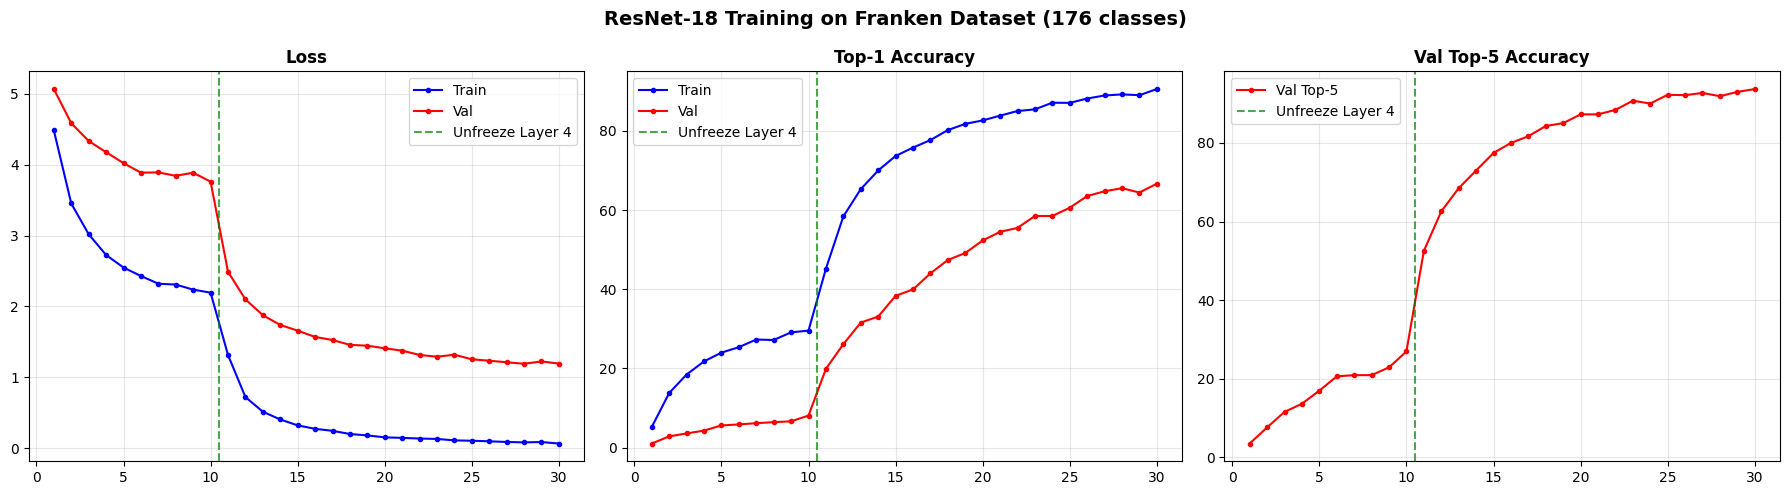

In [12]:
# -- Learning curves (both phases combined) --------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Combine histories
all_tl = history_3a['train_loss'] + history_3b['train_loss']
all_vl = history_3a['val_loss'] + history_3b['val_loss']
all_va = history_3a['val_acc1'] + history_3b['val_acc1']
all_ta = history_3a['train_acc1'] + history_3b['train_acc1']
all_va5 = history_3a['val_acc5'] + history_3b['val_acc5']
ep = range(1, len(all_tl) + 1)
split_ep = len(history_3a['train_loss'])  # where Phase 3a ends

# Loss
axes[0].plot(ep, all_tl, 'b-o', ms=3, label='Train')
axes[0].plot(ep, all_vl, 'r-o', ms=3, label='Val')
axes[0].axvline(split_ep + 0.5, color='green', linestyle='--', alpha=0.7, label='Unfreeze Layer 4')
axes[0].set_title('Loss', fontweight='bold'); axes[0].legend(); axes[0].grid(alpha=0.3)

# Top-1 Accuracy
axes[1].plot(ep, [a*100 for a in all_ta], 'b-o', ms=3, label='Train')
axes[1].plot(ep, [a*100 for a in all_va], 'r-o', ms=3, label='Val')
axes[1].axvline(split_ep + 0.5, color='green', linestyle='--', alpha=0.7, label='Unfreeze Layer 4')
axes[1].set_title('Top-1 Accuracy', fontweight='bold'); axes[1].legend(); axes[1].grid(alpha=0.3)

# Top-5 Accuracy
axes[2].plot(ep, [a*100 for a in all_va5], 'r-o', ms=3, label='Val Top-5')
axes[2].axvline(split_ep + 0.5, color='green', linestyle='--', alpha=0.7, label='Unfreeze Layer 4')
axes[2].set_title('Val Top-5 Accuracy', fontweight='bold'); axes[2].legend(); axes[2].grid(alpha=0.3)

plt.suptitle(f'ResNet-18 Training on Franken Dataset ({NUM_CLASSES} classes)', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.savefig('resnet18_training_curves.png', dpi=150, bbox_inches='tight'); plt.show()

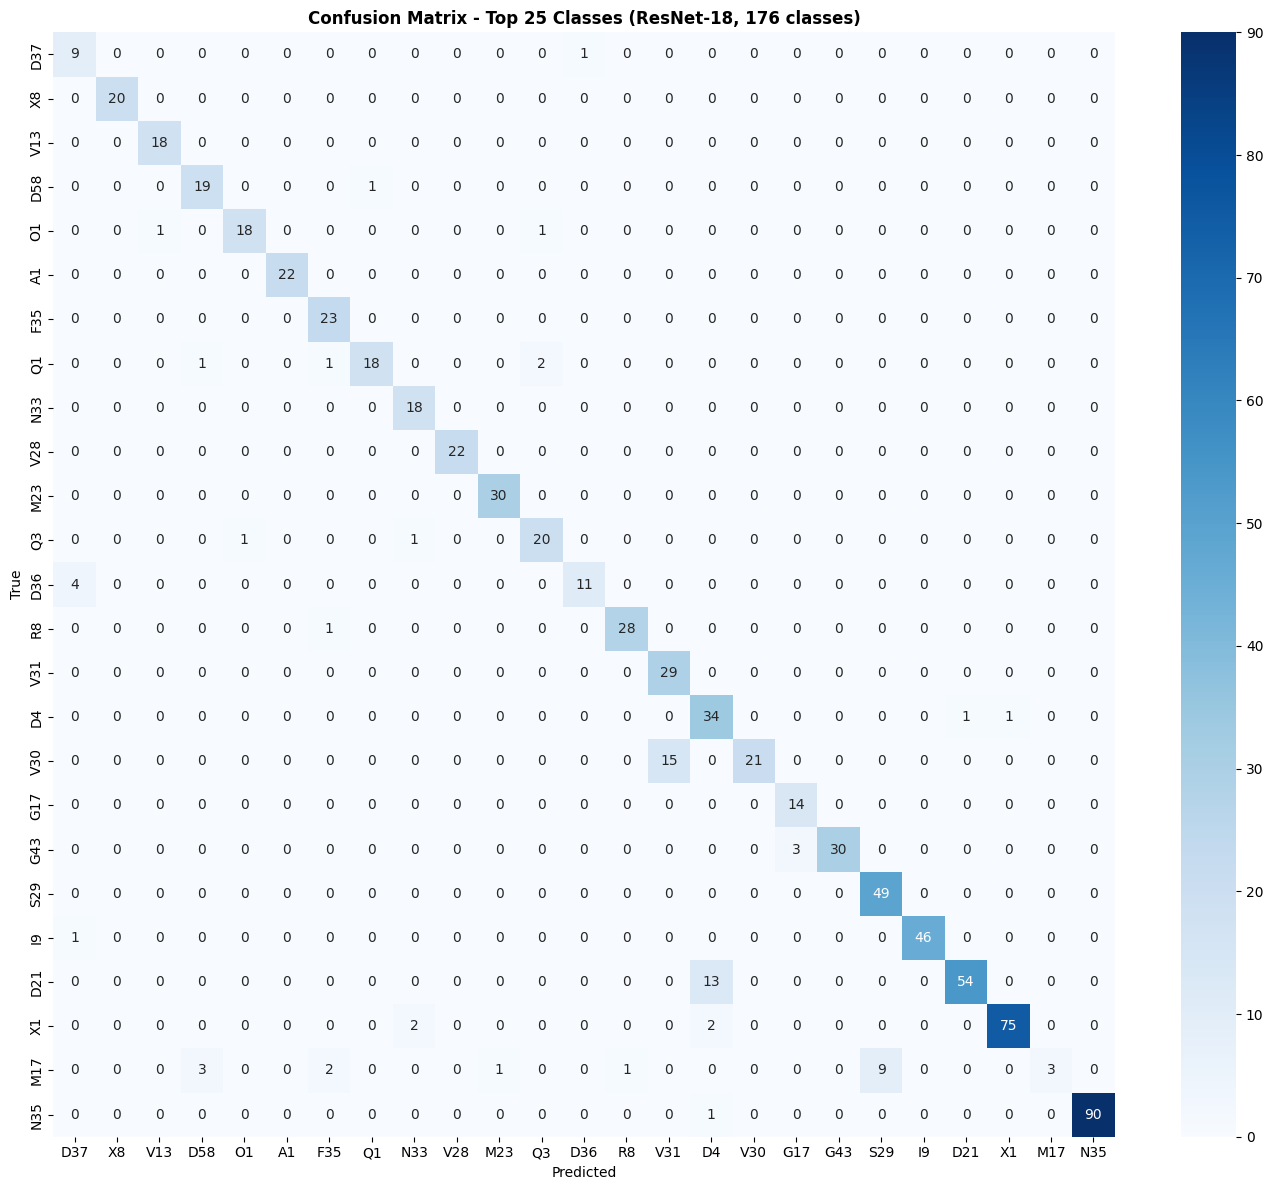

In [13]:
# -- Confusion matrix (top 25 classes) -------------------------------------
top25_idx = np.argsort(np.bincount(labels))[-25:]
mask = np.isin(labels, top25_idx)
cm = confusion_matrix(labels[mask], preds[mask], labels=top25_idx)
top25_names = [idx_to_label[i] for i in top25_idx]

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=top25_names, yticklabels=top25_names, ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title(f'Confusion Matrix - Top 25 Classes (ResNet-18, {NUM_CLASSES} classes)', fontweight='bold')
plt.tight_layout(); plt.savefig('confusion_matrix_resnet18.png', dpi=150, bbox_inches='tight'); plt.show()

In [14]:
# -- Per-Gardiner-category accuracy ----------------------------------------
cat_correct = Counter(); cat_total = Counter()
for true, pred in zip(labels, preds):
    lbl = idx_to_label[true]
    prefix = 'AA' if lbl.startswith('AA') else lbl[0]
    cat_total[prefix] += 1
    if true == pred: cat_correct[prefix] += 1

print(f'  {"Category":>10s}  {"Samples":>8s}  {"Correct":>8s}  {"Accuracy":>10s}')
print(f'  {"-"*10}  {"-"*8}  {"-"*8}  {"-"*10}')
for cat in sorted(cat_total.keys(), key=lambda c: -cat_total[c]):
    acc = cat_correct[cat] / cat_total[cat] * 100
    print(f'  {cat:>10s}  {cat_total[cat]:>8d}  {cat_correct[cat]:>8d}  {acc:>9.1f}%')

    Category   Samples   Correct    Accuracy
  ----------  --------  --------  ----------
           D       307       210       68.4%
           N       233       156       67.0%
           M       185        58       31.4%
           V       157       105       66.9%
           G       147        76       51.7%
           X       123        98       79.7%
           S       115        87       75.7%
           I        84        58       69.0%
           O        83        66       79.5%
           F        71        57       80.3%
           R        68        56       82.4%
           Q        60        38       63.3%
           A        47        39       83.0%
           Y        46        34       73.9%
           W        43        31       72.1%
           U        41        35       85.4%
           Z        31        21       67.7%
           E        28        24       85.7%
          AA        17        11       64.7%
           H        16        13       81.2%
          

# **<span style="color: #c9a84c;">𓏏 Section 8 - Feature Extraction for Phase 3 Transformer</span>**

<hr style="height: 6px; width: 100%; background: linear-gradient(90deg, transparent, #c9a84c, #f0d080, #c9a84c, transparent); border: none; margin-top: 10px; margin-bottom: 10px;">

<span style="color: #a8c4d8;">The trained ResNet-18 will be reused as a **frozen feature extractor** in Phase 3. The `extract_features()` method returns the 512-dim vector before the classifier head - this feeds directly into the Transformer projection layer.</span>


In [15]:
# -- Verify feature extraction works ---------------------------------------
model.eval()
sample_batch = next(iter(test_loader))
with torch.no_grad():
    features = model.extract_features(sample_batch[0][:4].to(DEVICE))

print(f'Feature extraction test:')
print(f'  Input shape  : {sample_batch[0][:4].shape}')  # (4, 3, 224, 224)
print(f'  Output shape : {features.shape}')              # (4, 512)
print(f'  Feature dim  : {features.shape[1]}')
print(f'\n✓ Feature extractor ready for Phase 2 (n-gram) and Phase 3 (transformer).')

Feature extraction test:
  Input shape  : torch.Size([4, 3, 224, 224])
  Output shape : torch.Size([4, 512])
  Feature dim  : 512

✓ Feature extractor ready for Phase 2 (n-gram) and Phase 3 (transformer).


# **<span style="color: #c9a84c;">💾 Section 9 - Save All Artifacts</span>**

<hr style="height: 6px; width: 100%; background: linear-gradient(90deg, transparent, #c9a84c, #f0d080, #c9a84c, transparent); border: none; margin-top: 10px; margin-bottom: 10px;">

In [16]:
# -- Save everything for Phase 2 & 3 --------------------------------------
SAVE_DIR = Path('/kaggle/working')

# Save results JSON
results = {
    'model': 'ResNet-18 (ImageNet pretrained, frozen layers, fine-tuned on Glyph2025)',
    'dataset': 'Glyph2025 (EHT + Franken merged, 13,287 images)',
    'num_classes': NUM_CLASSES,
    'train_images': len(df_train),
    'val_images': len(df_val),
    'test_images': len(df_test),
    'test_top1': float(te_a1),
    'test_top5': float(te_a5),
    'macro_f1': float(macro_f1),
    'weighted_f1': float(weighted_f1),
    'macro_precision': float(macro_prec),
    'macro_recall': float(macro_rec),
    'best_val_top1': float(best_val_acc),
    'feature_dim': model.feat_dim,
}

with open(SAVE_DIR / 'phase1_results.json', 'w') as f:
    json.dump(results, f, indent=2)

# Save splits for reproducibility
df_train.to_csv(SAVE_DIR / 'split_train.csv', index=False)
df_val.to_csv(SAVE_DIR / 'split_val.csv', index=False)
df_test.to_csv(SAVE_DIR / 'split_test.csv', index=False)

print('Artifacts saved:')
for f in sorted(SAVE_DIR.glob('*')):
    if f.suffix in ['.json', '.png', '.pth', '.csv']:
        print(f'  {f.name}')

print(f'\n✓ Phase 1 complete.')
print(f'  ResNet-18 checkpoint: resnet18_best.pth')
print(f'  Label maps: label_map.json, idx_to_label.json')
print(f'  These will be loaded by Phase 2 (CNN+N-gram) and Phase 3 (CNN+Transformer).')

Artifacts saved:
  confusion_matrix_resnet18.png
  phase1_results.json
  resnet18_best.pth
  resnet18_training_curves.png
  split_test.csv
  split_train.csv
  split_val.csv

✓ Phase 1 complete.
  ResNet-18 checkpoint: resnet18_best.pth
  Label maps: label_map.json, idx_to_label.json
  These will be loaded by Phase 2 (CNN+N-gram) and Phase 3 (CNN+Transformer).
